#### Hypothesis 2: There are specific categories that are causing decline in median order value

In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt


In [3]:
# loading the data
data = pd.read_parquet("../../data/processed/superstore/data.parquet")
orders = pd.read_parquet("../../data/processed/superstore/orders.parquet")
orders_agg = pd.read_parquet("../../data/processed/superstore/orders_agg.parquet")
dates = pd.read_parquet("../../data/processed/superstore/dates.parquet")
product = pd.read_parquet("../../data/processed/superstore/product.parquet")

##### Revenue trend by category

In [4]:
# revenue by year and category | Year-over-year growth
category_revenue =  orders[["Product ID", "Order Date","Sales"]].merge(
    dates[["date","year","month_num","month"]], 
    left_on="Order Date", right_on="date").merge(
        product[["product_id","Product ID", "Category", 
                 "Sub-Category"]], 
        on="Product ID" )[["year","Category", "Sales"]].groupby(
            ["year","Category"]
        )["Sales"].sum().reset_index().pivot(
            index="Category",
            columns = "year",
            values = "Sales"
        )

category_revenue.pct_change(axis=1).round(2)

year,2014,2015,2016,2017
Category,,,,
Furniture,NaN,0.08,0.17,0.06
Office Supplies,NaN,-0.09,0.35,0.34
Technology,NaN,-0.05,0.38,0.20


- Technology experienced slower revenue growth in 2017
- Furniture showed relatively weak revenue growth
- Office supplies even though dropped a bit once in 2015 but further on maintained a strong revenue growth

This suggests that not every category contributed equally to revenue performance

##### Quantity growth by Category

In [5]:
# quantity trend by Category

category_growth = orders[["Product ID", "Order Date","Quantity"]].merge(
    dates[["date","year","month_num","month"]], 
    left_on="Order Date", right_on="date").merge(
        product[["product_id","Product ID", "Category", 
                 "Sub-Category"]], 
        on="Product ID" )[["year","Category", "Quantity"]].groupby(
            ["year","Category"]
        )["Quantity"].sum().reset_index().pivot(
            index="Category",
            columns = "year",
            values = "Quantity"
        )

category_growth.pct_change(axis=1).round(2)

year,2014,2015,2016,2017
Category,,,,
Furniture,NaN,0.10,0.23,0.11
Office Supplies,NaN,0.03,0.28,0.28
Technology,NaN,0.08,0.15,0.38


In [ ]:
# revenue and quantity trend comparison
category_rev_quant = category_revenue.pct_change(axis=1).round(2).merge(
    category_growth.pct_change(axis=1).round(2), 
    suffixes=("_Revenue","_Quantity"),
    left_on="Category",
    right_on="Category")[[
                          "2015_Revenue","2015_Quantity",
                          "2016_Revenue","2016_Quantity",
                          "2017_Revenue","2017_Quantity"]].reset_index()

category_rev_quant

year,Category,2015_Revenue,2015_Quantity,2016_Revenue,2016_Quantity,2017_Revenue,2017_Quantity
0,Furniture,0.08,0.10,0.17,0.23,0.06,0.11
1,Office Supplies,-0.09,0.03,0.35,0.28,0.34,0.28
2,Technology,-0.05,0.08,0.38,0.15,0.20,0.38


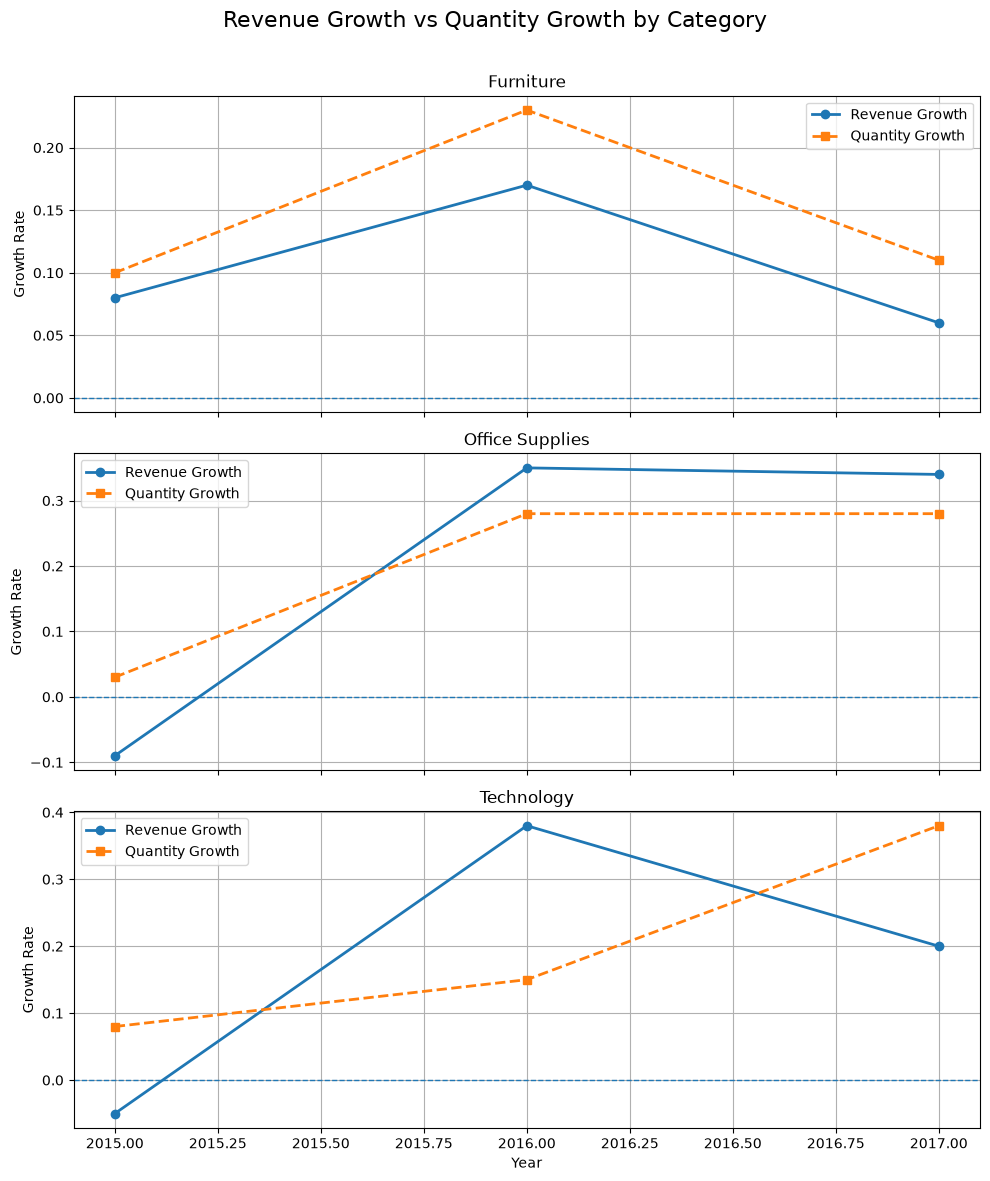

In [ ]:
# Visualizing the trend
# Years on the x-axis
years = [2015, 2016, 2017]

# Create 3 stacked subplots
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 12), sharex=True)

for i, category in enumerate(category_rev_quant['Category']):

    row = category_rev_quant[category_rev_quant['Category'] == category]

    revenue = [
        row['2015_Revenue'].values[0],
        row['2016_Revenue'].values[0],
        row['2017_Revenue'].values[0]
    ]

    quantity = [
        row['2015_Quantity'].values[0],
        row['2016_Quantity'].values[0],
        row['2017_Quantity'].values[0]
    ]

    axes[i].plot(years, revenue,
                 marker='o',
                 linewidth=2,
                 label='Revenue Growth')

    axes[i].plot(years, quantity,
                 marker='s',
                 linewidth=2,
                 linestyle='--',
                 label='Quantity Growth')

    axes[i].set_title(category)
    axes[i].set_ylabel('Growth Rate')
    axes[i].axhline(0, linestyle='--', linewidth=1)
    axes[i].grid(True)
    axes[i].legend()

# Shared x-axis label
axes[-1].set_xlabel('Year')

# Main title
fig.suptitle('Revenue Growth vs Quantity Growth by Category', fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

##### Furniture: 
- Across three years the quantity growth exceeded revenue growth
- Business sold more furniture products each year, but revenue increased more slowly than sales volume.
    - This suggests that additional sales generated less revenue  per unit or per order than before. Possible reasons include discounting, lower-priced product purchases or a shift toward less expensive furniture items.

##### Office Supplies: 
- Expereinced an initial decline but recovered substantially. Revenue growth outpaced quantity growth after 2015, suggesting improved revenue generation per unit sold
- This category generated increasing revenue from each additional unit sold.
- Therefore, it is unlikely to be a major contributor to the overall decline in Median Order Value

##### Technology: 
- Showed inconsistent growth, initial decline in revenue and then increase. However, quantity growth is not at all proportional to revenue growth. Higher sales volume did proportionally translate into higher revenue.
- Customers bought more tech products, but those purchases generated proportionally less revneue.
    - This pattern reflects increased sales of lower-priced tech products, heavier disocunting or changes in the product mix.


In [ ]:
# Median order value by Category
category_mov=  orders[["Product ID", "Order Date","Sales"]].merge(
    dates[["date","year","month_num","month"]], 
    left_on="Order Date", right_on="date").merge(
        product[["product_id","Product ID", "Category", 
                 "Sub-Category"]], 
        on="Product ID" )[["year","Category", "Sales"]].groupby(
            ["year","Category"]
        )["Sales"].median().reset_index().pivot(
            index="Category",
            columns = "year",
            values = "Sales"
        )
category_mov.pct_change(axis=1).round(2)

This confirms that technology and some extent to furniture as well show declining median order value by category.
Hence, these categories are contributing overall decline in revenue performance

In [32]:
# revenue share (product mix)

category_share= orders[["Product ID", "Order Date","Sales"]].merge(
    dates[["date","year","month_num","month"]], 
    left_on="Order Date", right_on="date").merge(
        product[["product_id","Product ID", "Category", 
                 "Sub-Category"]], 
        on="Product ID" )[["year","Category", "Sales"]].groupby(
            ["year","Category"]
        )["Sales"].sum().groupby(
            level=0
        ).transform(
            lambda x: x/x.sum()*100
        ).reset_index( name='Revenue_Share').pivot(
            index="Category",
            columns = "year",
            values = "Revenue_Share"
        )

category_share.round(2)

year,2014,2015,2016,2017
Category,,,,
Furniture,32.46,35.83,32.31,28.69
Office Supplies,30.78,28.50,29.67,33.14
Technology,36.76,35.67,38.02,38.17


- Furniture's total revenue contribution declined from ~32% to ~28% over the analysis period.
    - Therefore, its a smaller contributor to overall business over time.
    - May require further investigation into pricing, customer demand, product mix or promotional strategies to understand why it is contributing less to total revenue
- Office supplies strengthened its contribution to total revenue over time even after falling a bit in 2015
    - This category strengthened its market performance and became a more significant driver of company revenue
    - It could be due to stronger demand, more effective pricing, successful promotions or increased customer purchases.
- Technology remained company's dominant revenue-generating category with only minor fluctuations in its revenue share.
    - Indiciates that technology is a core business category and plays a critical role in maintaining overall revenue performance.
    - Because of its large contribution, even small changes in tech performance could have a significant impact on total company revenue

### RESULSTS
It partially supports the hypothesis
- Technology provides the strongest evidence supporting the hypothesis. Sales volume increased much faster than revenue, suggesting declining revnenue generated per sale or oorder.
- Furniture also shows a similar pattern, although the gap between quantity and revenue growth is smaller.
- Office supplies does not support the hypothesis because revenue growth receovered and generally outpaced quantity growth after 2015.